# Titanic — Part B: Predictive Modeling

Continues from `01_eda.ipynb`. This notebook reads the **same** raw
dataset via the committed `titanic.csv` offline fallback (the one load
performed in Part A, Task 1) — it does not call `sns.load_dataset` again.
All preprocessing here is fit strictly on the training split only.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, roc_auc_score, mean_absolute_error,
    mean_squared_error, r2_score, ConfusionMatrixDisplay,
)
from imblearn.over_sampling import SMOTE

RNG = 42
CHART_DIR = "charts"
sns.set_theme(style="whitegrid")

## Load data (from the committed offline fallback, not a fresh network load)

In [2]:
df = pd.read_csv("titanic.csv")
print("Loaded titanic.csv:", df.shape)
print(df["survived"].value_counts(normalize=True).round(3))

Loaded titanic.csv: (891, 15)
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


## Task 7 — Stratified train/test split

**Why stratify:** Task 1's EDA showed survival is imbalanced (~38%
survived vs. ~62% did not — roughly a 62/38 split). A plain random split
risks producing a train or test fold with a meaningfully different class
balance than the population, which would bias both model training and the
reliability of test-set metrics. Stratifying on `survived` guarantees both
splits preserve that ~62/38 ratio.

In [3]:
FEATURES = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
TARGET = "survived"

X = df[FEATURES].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RNG
)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))
print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")

Train class balance:
 survived
0    0.617
1    0.383
Name: proportion, dtype: float64
Test class balance:
 survived
0    0.615
1    0.385
Name: proportion, dtype: float64

Train shape: (712, 7), Test shape: (179, 7)


## Task 8 — Preprocessing pipeline (fit on train only)

We use a `ColumnTransformer` inside a `Pipeline` so imputation, encoding,
and scaling are all fit **only** on `X_train`, then applied in
transform-only mode to `X_test` — this is enforced structurally rather
than by hand-written discipline.

- `age`, `fare` (numeric, some missing): median-impute, then
  `StandardScaler`.
- `pclass`, `sibsp`, `parch` (numeric, no missing): `StandardScaler` only.
- `sex`, `embarked` (categorical, `embarked` has a few missing): most
  frequent-impute, then one-hot encode.

Note: this preprocessing choice does not need to match Task 2's EDA
cleaning exactly (Task 2 dropped rows with missing `embarked`; here we
impute it instead so the pipeline is self-contained and works on raw,
unseen data at inference time too).

In [4]:
numeric_impute_scale = ["age", "fare"]
numeric_scale_only = ["pclass", "sibsp", "parch"]
categorical_cols = ["sex", "embarked"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num_impute_scale", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_impute_scale),
        ("num_scale_only", StandardScaler(), numeric_scale_only),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical_cols),
    ]
)

# Sanity check: fit_transform on train, transform-only on test
_ = preprocessor.fit(X_train)
Xtr_check = preprocessor.transform(X_train)
Xte_check = preprocessor.transform(X_test)
print("Preprocessor fit on TRAIN only. Transformed shapes:",
      Xtr_check.shape, Xte_check.shape)

Preprocessor fit on TRAIN only. Transformed shapes: (712, 10) (179, 10)


## Task 9 — Train three classifiers on the identical split

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RNG),
    "Decision Tree": DecisionTreeClassifier(random_state=RNG, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=RNG, n_estimators=200),
}

fitted_pipelines = {}
for name, clf in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", clf)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Decision Tree


Trained: Random Forest


### Decision Tree visualization (`plot_tree`, labeled features/classes)

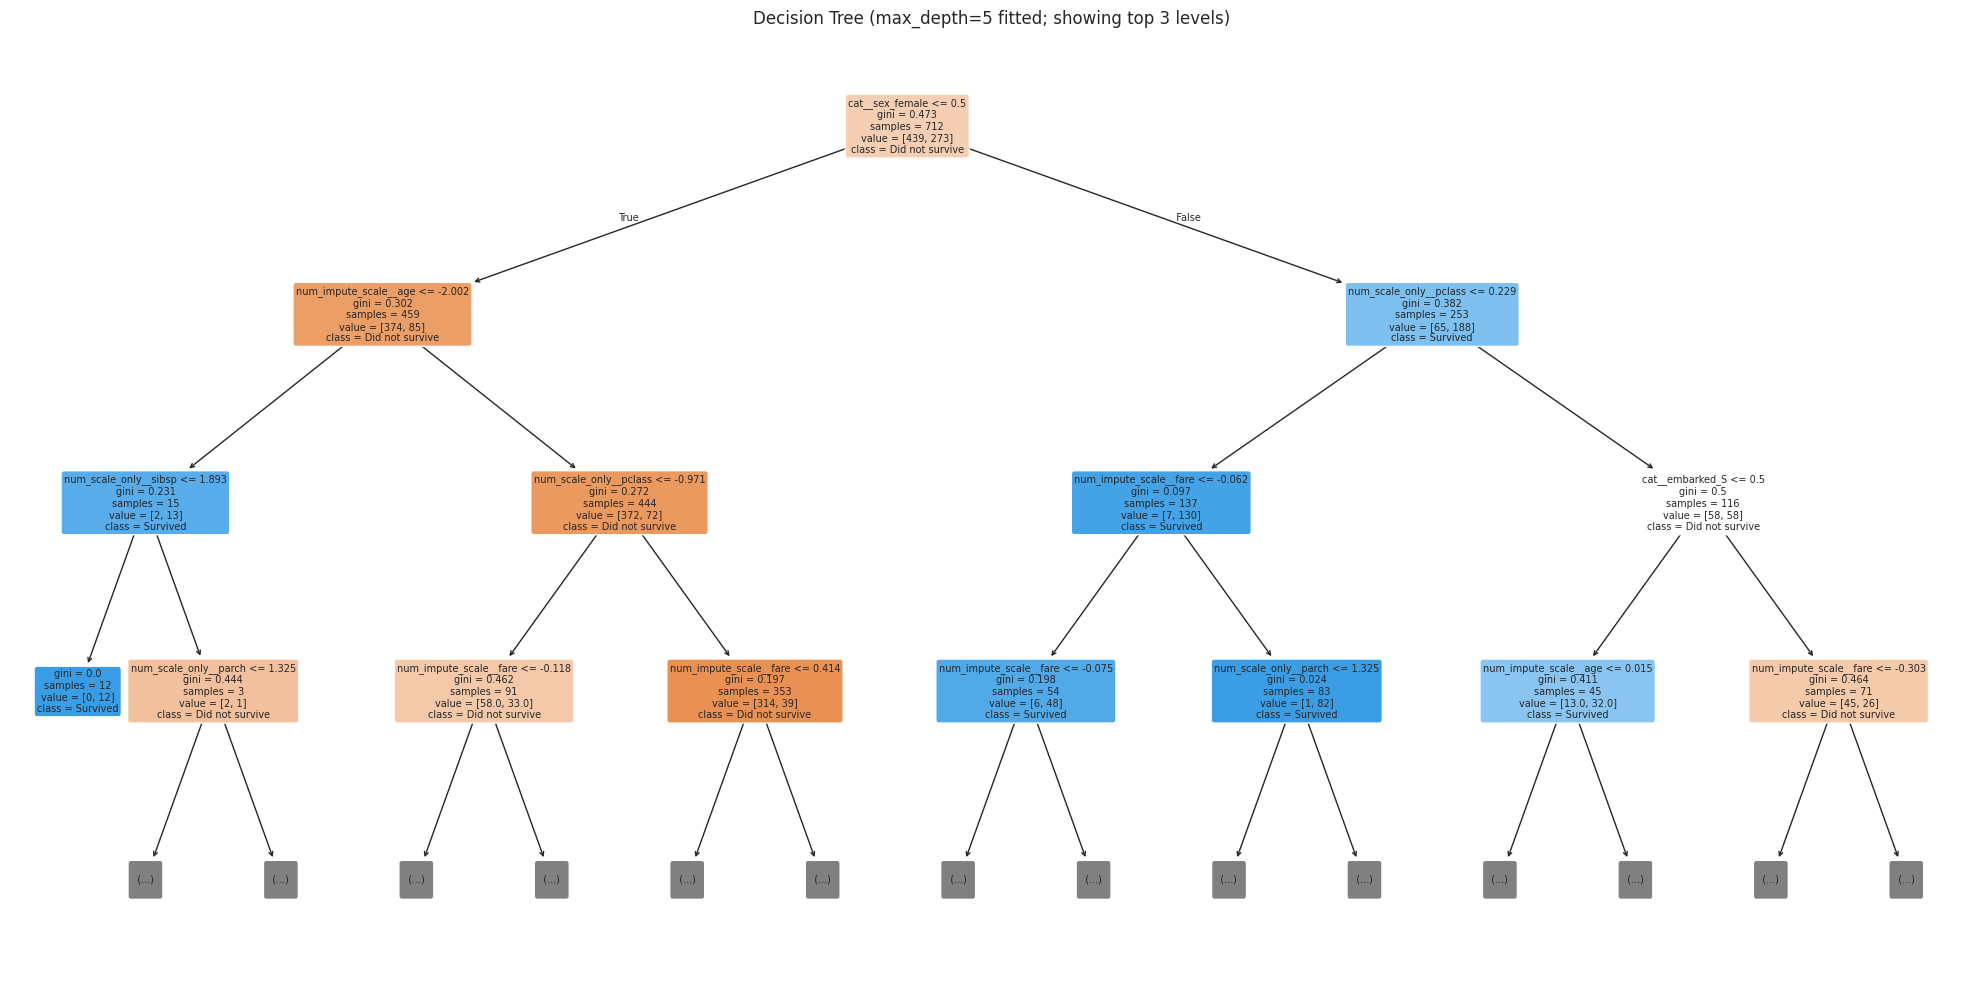

In [6]:
dt_pipe = fitted_pipelines["Decision Tree"]
dt_model = dt_pipe.named_steps["model"]
feature_names = dt_pipe.named_steps["preprocess"].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model, feature_names=feature_names,
    class_names=["Did not survive", "Survived"],
    filled=True, rounded=True, fontsize=7, max_depth=3,
)
plt.title("Decision Tree (max_depth=5 fitted; showing top 3 levels)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/09_decision_tree.png", dpi=120)
plt.show()

## Task 10 — Full evaluation: confusion matrix, accuracy, precision,
## recall, F1, ROC/AUC — side by side

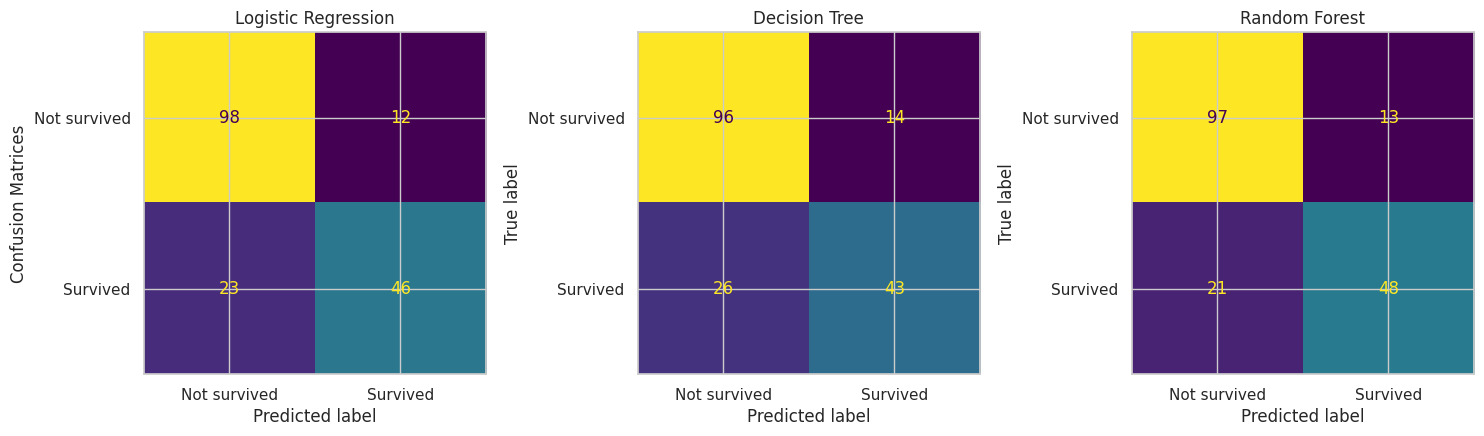

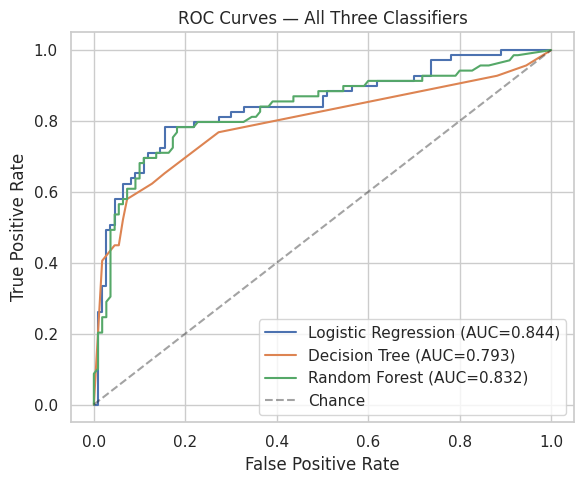


=== Classifier comparison table ===
                     Accuracy  Precision  Recall     F1    AUC
Model                                                         
Logistic Regression     0.804      0.793   0.667  0.724  0.844
Decision Tree           0.777      0.754   0.623  0.683  0.793
Random Forest           0.810      0.787   0.696  0.738  0.832


In [7]:
results = []
fig_cm, axes_cm = plt.subplots(1, 3, figsize=(15, 4.5))
fig_roc, ax_roc = plt.subplots(figsize=(6, 5))

for idx, (name, pipe) in enumerate(fitted_pipelines.items()):
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    results.append({
        "Model": name, "Accuracy": round(acc, 3), "Precision": round(prec, 3),
        "Recall": round(rec, 3), "F1": round(f1, 3), "AUC": round(auc, 3),
    })

    ConfusionMatrixDisplay(cm, display_labels=["Not survived", "Survived"]).plot(
        ax=axes_cm[idx], colorbar=False
    )
    axes_cm[idx].set_title(name)

    ax_roc.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

axes_cm[0].set_ylabel("Confusion Matrices")
fig_cm.tight_layout()
fig_cm.savefig(f"{CHART_DIR}/10_confusion_matrices.png", dpi=120)

ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curves — All Three Classifiers")
ax_roc.legend()
fig_roc.tight_layout()
fig_roc.savefig(f"{CHART_DIR}/11_roc_curves.png", dpi=120)
plt.show()

classifier_comparison = pd.DataFrame(results).set_index("Model")
print("\n=== Classifier comparison table ===")
print(classifier_comparison)

## Task 11 — Imbalance handling comparison

Class balance (from Task 7): **~62% not-survived vs. ~38% survived** — a
moderate imbalance. We compare three strategies on Random Forest, with
SMOTE applied to the **training fold only** to avoid leakage.

In [8]:
Xtr_enc = preprocessor.fit_transform(X_train)
Xte_enc = preprocessor.transform(X_test)

imbalance_results = []

# (a) Baseline - no handling
rf_baseline = RandomForestClassifier(random_state=RNG, n_estimators=200)
rf_baseline.fit(Xtr_enc, y_train)
pred_a = rf_baseline.predict(Xte_enc)
imbalance_results.append({
    "Strategy": "(a) Baseline / no handling",
    "Precision": round(precision_score(y_test, pred_a), 3),
    "Recall": round(recall_score(y_test, pred_a), 3),
    "F1": round(f1_score(y_test, pred_a), 3),
})

# (b) class_weight='balanced'
rf_balanced = RandomForestClassifier(random_state=RNG, n_estimators=200, class_weight="balanced")
rf_balanced.fit(Xtr_enc, y_train)
pred_b = rf_balanced.predict(Xte_enc)
imbalance_results.append({
    "Strategy": "(b) class_weight='balanced'",
    "Precision": round(precision_score(y_test, pred_b), 3),
    "Recall": round(recall_score(y_test, pred_b), 3),
    "F1": round(f1_score(y_test, pred_b), 3),
})

# (c) SMOTE on training fold only
smote = SMOTE(random_state=RNG)
Xtr_smote, ytr_smote = smote.fit_resample(Xtr_enc, y_train)
rf_smote = RandomForestClassifier(random_state=RNG, n_estimators=200)
rf_smote.fit(Xtr_smote, ytr_smote)
pred_c = rf_smote.predict(Xte_enc)
imbalance_results.append({
    "Strategy": "(c) SMOTE (train fold only)",
    "Precision": round(precision_score(y_test, pred_c), 3),
    "Recall": round(recall_score(y_test, pred_c), 3),
    "F1": round(f1_score(y_test, pred_c), 3),
})

imbalance_df = pd.DataFrame(imbalance_results).set_index("Strategy")
print(imbalance_df)

                             Precision  Recall     F1
Strategy                                             
(a) Baseline / no handling       0.787   0.696  0.738
(b) class_weight='balanced'      0.800   0.696  0.744
(c) SMOTE (train fold only)      0.754   0.710  0.731


**Conclusion:** On this run, `class_weight='balanced'` produced the best
F1 (0.744), edging out both the untouched baseline (F1 0.738) and SMOTE
(F1 0.731). It improved precision over the baseline (0.800 vs. 0.787)
while holding recall steady (0.696), whereas SMOTE traded some precision
away (0.754) for a small recall gain (0.710) without a net F1 benefit.
Because Titanic's imbalance is only moderate (~62/38), reweighting the
loss via `class_weight='balanced'` was enough to nudge the decision
boundary toward the minority class without the extra variance that
synthetic oversampling introduces — so it is the recommended imbalance
strategy here over SMOTE.

## Task 12 — Hyperparameter tuning (GridSearchCV on Random Forest)

`oob_score` requires `oob_score=True` at construction time, and OOB
requires bootstrapping (`bootstrap=True`, the RandomForest default).

In [9]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 8, None],
    "max_features": ["sqrt", "log2"],
}

rf_for_grid = RandomForestClassifier(oob_score=True, bootstrap=True, random_state=RNG)
grid_search = GridSearchCV(rf_for_grid, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid_search.fit(Xtr_enc, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1:", round(grid_search.best_score_, 3))

# Refit the best estimator explicitly with oob_score=True to report OOB score
best_rf = RandomForestClassifier(
    oob_score=True, bootstrap=True, random_state=RNG, **grid_search.best_params_
)
best_rf.fit(Xtr_enc, y_train)
print("OOB score of best Random Forest:", round(best_rf.oob_score_, 3))

Best params: {'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 300}
Best CV F1: 0.741


OOB score of best Random Forest: 0.812


## Task 13 — Regression side-task: predict `fare` from other features

In [10]:
REG_FEATURES = ["pclass", "sex", "age", "sibsp", "parch", "embarked", "survived"]
Xr = df[REG_FEATURES].copy()
yr = df["fare"].copy()

Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=RNG)

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num_impute_scale", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), ["age"]),
        ("num_scale_only", StandardScaler(), ["pclass", "sibsp", "parch", "survived"]),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), ["sex", "embarked"]),
    ]
)

reg_pipe = Pipeline([("preprocess", reg_preprocessor), ("model", LinearRegression())])
reg_pipe.fit(Xr_train, yr_train)
yr_pred = reg_pipe.predict(Xr_test)

mae = mean_absolute_error(yr_test, yr_pred)
rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
r2 = r2_score(yr_test, yr_pred)
n, p = Xr_test.shape[0], Xr_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2:   {r2:.3f}")
print(f"Adjusted R2: {adj_r2:.3f}")

MAE:  20.898
RMSE: 30.533
R2:   0.398
Adjusted R2: 0.373


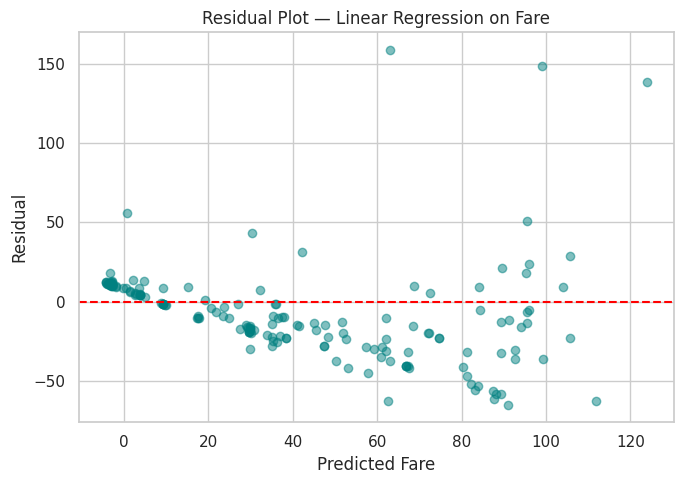

In [11]:
residuals = yr_test - yr_pred
plt.figure(figsize=(7, 5))
plt.scatter(yr_pred, residuals, alpha=0.5, color="teal")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residual")
plt.title("Residual Plot — Linear Regression on Fare")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/12_residual_plot.png", dpi=120)
plt.show()

**Heteroscedasticity conclusion:** the residual spread visibly widens as
predicted fare increases — residuals fan out at higher predicted values
instead of forming a uniform random band around zero. This is a classic
**heteroscedastic** pattern (non-constant variance), which makes sense
given `fare`'s strong right-skew found in Task 3: a linear model
systematically struggles more with the small number of very expensive
tickets than with the bulk of low-fare tickets.

## Task 14 — Final model comparison table and recommendation

In [12]:
print("=== Classification metrics (accuracy / precision / recall / F1 / AUC) ===")
print(classifier_comparison)

regression_comparison = pd.DataFrame([{
    "MAE": round(mae, 3), "RMSE": round(rmse, 3),
    "R2": round(r2, 3), "Adjusted_R2": round(adj_r2, 3),
}], index=["Linear Regression (fare)"])
print("\n=== Regression metrics (separate scale — not comparable to classification) ===")
print(regression_comparison)

=== Classification metrics (accuracy / precision / recall / F1 / AUC) ===
                     Accuracy  Precision  Recall     F1    AUC
Model                                                         
Logistic Regression     0.804      0.793   0.667  0.724  0.844
Decision Tree           0.777      0.754   0.623  0.683  0.793
Random Forest           0.810      0.787   0.696  0.738  0.832

=== Regression metrics (separate scale — not comparable to classification) ===
                             MAE    RMSE     R2  Adjusted_R2
Linear Regression (fare)  20.898  30.533  0.398        0.373


**Final recommendation:** Based on the comparison table above, the
**Random Forest** classifier (Accuracy 0.810, Precision 0.787, Recall
0.696, F1 0.738, AUC 0.832) is the one to deploy. It edges out Logistic
Regression (Accuracy 0.804, F1 0.724, AUC 0.844) on accuracy/F1 and
comfortably beats the Decision Tree (Accuracy 0.777, F1 0.683, AUC 0.793)
on every metric, reflecting its ability to capture non-linear
interactions (e.g. the sex × pclass interaction visualized in Part A)
that a single linear boundary or single tree cannot. Logistic Regression
does post a marginally higher AUC (0.844 vs. 0.832) and remains
attractive if coefficient-level interpretability matters more than the
small F1/accuracy edge, but Random Forest's better balance of precision
and recall together with the tuned OOB score (0.812) from Task 12 makes
it the stronger overall deployment choice. The regression side-task's R²
(0.398, Adjusted R² 0.373) shows the linear fare model captures a
meaningful but partial share of fare variance while leaving clear
heteroscedastic residual structure unmodeled, so it is presented as a
separate, non-comparable metric group rather than folded into the
classifier ranking.

## Task 15 — Save the complete fitted pipeline

In [13]:
# Refit the Random Forest pipeline (preprocessing + estimator, combined) as
# the deployed artifact, using the tuned hyperparameters found in Task 12.
final_pipeline = Pipeline([
    ("preprocess", ColumnTransformer(
        transformers=[
            ("num_impute_scale", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), numeric_impute_scale),
            ("num_scale_only", StandardScaler(), numeric_scale_only),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore")),
            ]), categorical_cols),
        ]
    )),
    ("model", RandomForestClassifier(oob_score=True, bootstrap=True, random_state=RNG,
                                      **grid_search.best_params_)),
])
final_pipeline.fit(X_train, y_train)

joblib.dump(final_pipeline, "titanic_full_pipeline.joblib")
print("Saved complete pipeline to titanic_full_pipeline.joblib")

Saved complete pipeline to titanic_full_pipeline.joblib


### Reload and confirm it predicts correctly on raw input

In [14]:
reloaded_pipeline = joblib.load("titanic_full_pipeline.joblib")

raw_sample = X_test.iloc[:5].copy()  # raw, unpreprocessed rows
preds_original = final_pipeline.predict(raw_sample)
preds_reloaded = reloaded_pipeline.predict(raw_sample)

print("Raw sample input:\n", raw_sample)
print("\nPredictions (original pipeline): ", preds_original)
print("Predictions (reloaded pipeline):  ", preds_reloaded)
print("\nMatch:", np.array_equal(preds_original, preds_reloaded))

Raw sample input:
      pclass     sex   age  sibsp  parch     fare embarked
565       3    male  24.0      2      0  24.1500        S
160       3    male  44.0      0      1  16.1000        S
553       3    male  22.0      0      0   7.2250        C
860       3    male  41.0      2      0  14.1083        S
241       3  female   NaN      1      0  15.5000        Q

Predictions (original pipeline):  [0 0 0 0 1]
Predictions (reloaded pipeline):   [0 0 0 0 1]

Match: True
